
# 05. Baseline Models: Most-Frequent, Unigram, Bigram, Trigram

## Why baselines matter
A neural model is only useful if it beats strong classical baselines.

## Theory
- **Most Frequent**: always predicts single most common token.
- **Unigram**: context-free token probabilities.
- **Bigram**: uses one previous token.
- **Trigram**: uses two previous tokens.


In [1]:

from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn

from utils.data import prepare_combined_corpus
from utils.evaluation import dataloader_metrics
from utils.models import MostFrequentWordModel, UnigramModel, BigramModel, TrigramModel
from utils.sequence_builder import build_dataloaders_from_ids
from utils.tokenization import NLTKTokenizerBackend, normalize_text
from utils.vocabulary import Vocabulary

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

bundle = prepare_combined_corpus(
    project_root=PROJECT_ROOT,
    include_wikitext=True,
    wikitext_train_tokens=120_000,
    wikitext_val_tokens=20_000,
    wikitext_test_tokens=20_000,
)

tokenizer = NLTKTokenizerBackend()
train_tokens = tokenizer.tokenize(normalize_text(bundle.train_text))
test_tokens = tokenizer.tokenize(normalize_text(bundle.test_text))

vocab = Vocabulary(min_freq=2, max_size=20_000)
vocab.build([train_tokens])

train_ids = vocab.encode_with_special(train_tokens)
test_ids = vocab.encode_with_special(test_tokens)

train_loader = build_dataloaders_from_ids(train_ids, context_len=5, batch_size=128, val_ratio=0, test_ratio=0)["train"]
test_loader = build_dataloaders_from_ids(test_ids, context_len=5, batch_size=128, val_ratio=0, test_ratio=0)["train"]


/home/ahmad/AI/Github/40 AI-ML Projects for Beginners/Core Machine Learning and Data Science/Building a Predictive Keyboard Model/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

from itertools import islice

criterion = nn.NLLLoss()
models = {
    "MostFrequent": MostFrequentWordModel(vocab_size=len(vocab)),
    "Unigram": UnigramModel(vocab_size=len(vocab), smoothing=1.0),
    "Bigram": BigramModel(vocab_size=len(vocab), smoothing=1.0),
    "Trigram": TrigramModel(vocab_size=len(vocab), smoothing=1.0),
}

rows = []
for name, model in models.items():
    model.fit(train_ids)
    small_eval_loader = islice(test_loader, 20)
    metrics = dataloader_metrics(model, small_eval_loader, criterion, device="cpu")
    rows.append({"model": name, **metrics})

baseline_df = pd.DataFrame(rows).sort_values("top5_accuracy", ascending=False)
baseline_df


,model,cross_entropy,perplexity,top1_accuracy,top3_accuracy,top5_accuracy,recall_at_3,recall_at_5,mrr
2,Bigram,7.555368,1.910972e+03,0.142187,0.265234,0.316797,0.265234,0.316797,0.218191
3,Trigram,7.812749,2.471916e+03,0.125000,0.233984,0.283203,0.233984,0.283203,0.182874
1,Unigram,6.341485,5.676389e+02,0.070312,0.207422,0.271094,0.207422,0.271094,0.168450
0,MostFrequent,25.936462,1.836803e+11,0.061328,0.167969,0.167969,0.167969,0.167969,0.061537


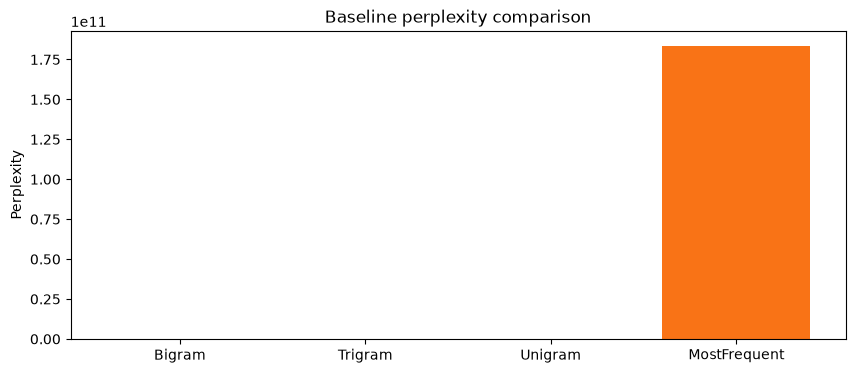

In [3]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(baseline_df["model"], baseline_df["perplexity"], color="#f97316")
plt.title("Baseline perplexity comparison")
plt.ylabel("Perplexity")
plt.show()



## Interpretation
Higher-order n-grams usually improve next-word quality but suffer sparsity on rare contexts.
Neural models next: better generalization under sparse patterns.
